<a href="https://colab.research.google.com/github/kbook6/tamu-engy604/blob/main/Prophet_Daily_Electricity_Underwood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Meta Prophet Forecasting Model


This report is a simple illustration of how Meta Prophet works. The main idea of applying Prophet to detect the anomalies is following:

1. build the Prophet forecasting model based on the current existing data
2. forecast the future values with its prediction interval
3. when the new data come, detect whether the data is beyond the prediction interval or not. If yes, assign the new data as `anomalies`

The Prophet forecasting model is based on the following formula
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t,$$
where $y(t)$ are the observations at time $t, t=1,\dots, T$ (training data). $g(t)$, $s(t)$, $h(t)$ are the **trend**, **seasonality**, **holiday** components respectively.

The trends are modeled by a logistic (S-shape trend) function or a piecewise linear function. The seasonalities are modeled by the Fourier series. The holidays are modeled by the indicators. The illustration of the detailed model can be found in https://peerj.com/preprints/3190v2/

The forecasting procedure is: first obtain the estimating of these three components $\widehat{g}(t)$, $\widehat{s}(t)$, $\widehat{h}(t)$. At the new time point $T+1$, forecast the output value $\widehat{y}(T+1) = \widehat{g}(T+1) + \widehat{s}(T+1) + \widehat{h}(T+1)$.

Pros of Prophet:

1. Flexibility: We can easily accommodate seasonality with multiple periods and let the analyst make different assumptions about trends.
2. Not neccessary time regularly spaced
3. Fast computation
4. Easily interpretable components


In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot

# Underwood Electricity Daily Data

We simply consider the electricity daily data (univariate time series) of Underwood Residence Hall. The data are presented below.

To utilize Meta Prophet forecasting model, the column names must be `ds` (the data timestamps) and `y` (the numeric values) respectively.

## Data Structure

In [2]:
# underwood electricity daily data
df1 = pd.DataFrame(pd.read_csv('https://raw.githubusercontent.com/jtao/AdvancedML/main/data/underwood.csv'))

In [3]:
df1

,Date,Consum
0,1/1/2019 12:00:00 AM,9304518.89
1,1/1/2019 12:15:00 AM,9304535.43
2,1/1/2019 12:30:00 AM,9304551.63
3,1/1/2019 12:45:00 AM,9304568.12
4,1/1/2019 1:00:00 AM,9304584.43
...,...,...
70155,12/31/2020 10:45:00 PM,10581718.72
70156,12/31/2020 11:00:00 PM,10581731.65
70157,12/31/2020 11:15:00 PM,10581744.35
70158,12/31/2020 11:30:00 PM,10581757.35


In [4]:
df1['Date'] = pd.DatetimeIndex(df1['Date'])

In [5]:
df1

,Date,Consum
0,2019-01-01 00:00:00,9304518.89
1,2019-01-01 00:15:00,9304535.43
2,2019-01-01 00:30:00,9304551.63
3,2019-01-01 00:45:00,9304568.12
4,2019-01-01 01:00:00,9304584.43
...,...,...
70155,2020-12-31 22:45:00,10581718.72
70156,2020-12-31 23:00:00,10581731.65
70157,2020-12-31 23:15:00,10581744.35
70158,2020-12-31 23:30:00,10581757.35


In [6]:
df1.columns = ["ds","y"]  # change the column names
print(df1.columns.values.tolist())
# df1 = df1.drop(index=[732])
df1

['ds', 'y']


,ds,y
0,2019-01-01 00:00:00,9304518.89
1,2019-01-01 00:15:00,9304535.43
2,2019-01-01 00:30:00,9304551.63
3,2019-01-01 00:45:00,9304568.12
4,2019-01-01 01:00:00,9304584.43
...,...,...
70155,2020-12-31 22:45:00,10581718.72
70156,2020-12-31 23:00:00,10581731.65
70157,2020-12-31 23:15:00,10581744.35
70158,2020-12-31 23:30:00,10581757.35


In [7]:
df1

,ds,y
0,2019-01-01 00:00:00,9304518.89
1,2019-01-01 00:15:00,9304535.43
2,2019-01-01 00:30:00,9304551.63
3,2019-01-01 00:45:00,9304568.12
4,2019-01-01 01:00:00,9304584.43
...,...,...
70155,2020-12-31 22:45:00,10581718.72
70156,2020-12-31 23:00:00,10581731.65
70157,2020-12-31 23:15:00,10581744.35
70158,2020-12-31 23:30:00,10581757.35


In [8]:
df1['y']=df1['y'].diff()

In [9]:
df1

,ds,y
0,2019-01-01 00:00:00,NaN
1,2019-01-01 00:15:00,16.54
2,2019-01-01 00:30:00,16.20
3,2019-01-01 00:45:00,16.49
4,2019-01-01 01:00:00,16.31
...,...,...
70155,2020-12-31 22:45:00,13.12
70156,2020-12-31 23:00:00,12.93
70157,2020-12-31 23:15:00,12.70
70158,2020-12-31 23:30:00,13.00


In [10]:
df1

,ds,y
0,2019-01-01 00:00:00,NaN
1,2019-01-01 00:15:00,16.54
2,2019-01-01 00:30:00,16.20
3,2019-01-01 00:45:00,16.49
4,2019-01-01 01:00:00,16.31
...,...,...
70155,2020-12-31 22:45:00,13.12
70156,2020-12-31 23:00:00,12.93
70157,2020-12-31 23:15:00,12.70
70158,2020-12-31 23:30:00,13.00


## Forecasting

We then use the Prophet function to forecast the future values. To verify the forecasting model, we separate the electricity daily data into two parts. First part is the values from day 1 to day 700 as the training data, while the second part is the rest of days.

The arguments `daily_seasonality`, `yearly_seasonality`, and `weekly_seasonality` can be manually controlled based on training data. `interval_width` from 0 to 1 controls the size of forecasting confidence intervals. The higher `interval_width` is, the larger confidence interval is.

We also consider the holiday effects during forecasting, since the holidays do affect the electricity consumptions.

In [11]:
!pip install prophet

In [12]:
# import Prophet
from prophet import Prophet

In [13]:
# model fitting and forecasting
m = Prophet(daily_seasonality = False, yearly_seasonality = True, weekly_seasonality = True,interval_width=0.8)


In [14]:
m

In [15]:
m.add_country_holidays(country_name='US')
m.fit(df1[1:7000])
future = m.make_future_dataframe(periods=3) # future 31 time points
forecast = m.predict(future) # forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
6997,2019-03-14 22:30:00,17.017271,14.468488,19.452915
6998,2019-03-14 22:45:00,17.014982,14.405672,19.457985
6999,2019-03-15 22:45:00,16.303152,13.944823,18.867617
7000,2019-03-16 22:45:00,16.072464,13.553342,18.566950
7001,2019-03-17 22:45:00,16.441718,14.000277,18.771099


In [16]:
# compare the true values with the forecast values
df1[6996:7000]

,ds,y
6996,2019-03-14 22:00:00,17.66
6997,2019-03-14 22:15:00,17.44
6998,2019-03-14 22:30:00,17.02
6999,2019-03-14 22:45:00,17.36


In [17]:
m.train_holiday_names

,0
0,New Year's Day
1,Memorial Day
2,Independence Day
3,Labor Day
4,Thanksgiving Day
5,Christmas Day
6,Martin Luther King Jr. Day
7,Washington's Birthday
8,Columbus Day
9,Veterans Day


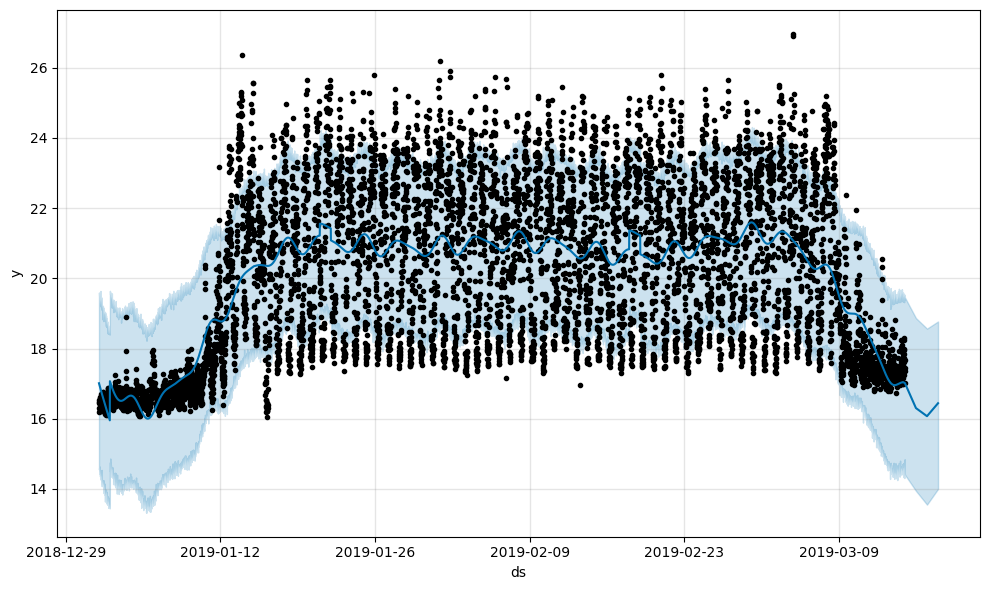

In [18]:
# plot the model fitting and forecasting with pointwise confidence intervals.
fig1 = m.plot(forecast)

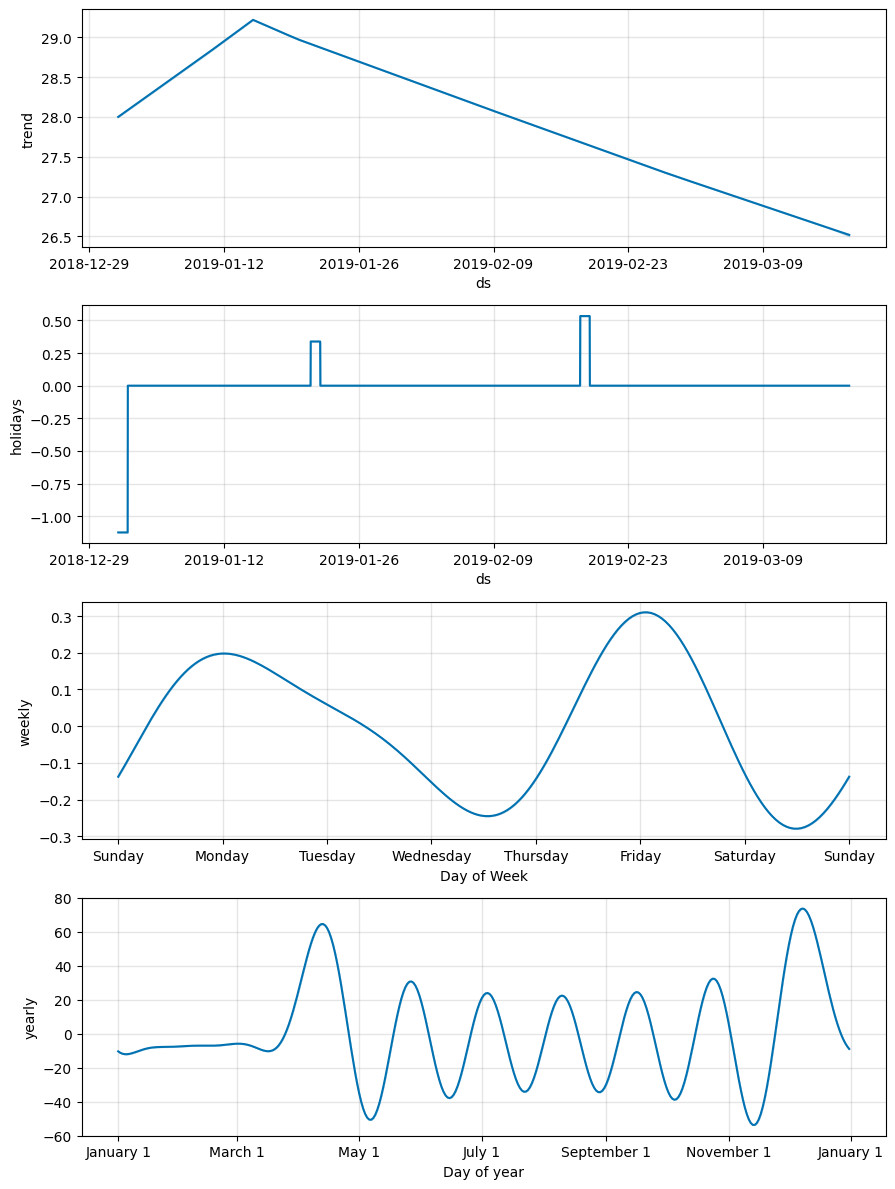

In [19]:
# different components
fig2 = m.plot_components(forecast)

In [20]:
# interactive plots
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

In [21]:
df1.describe()

,ds,y
count,70160,70159.000000
mean,2020-01-01 12:26:54.907354624,18.205093
min,2019-01-01 00:00:00,10.290000
25%,2019-07-02 18:41:15,16.430000
50%,2020-01-01 12:52:30,17.860000
75%,2020-07-02 07:03:45,20.220000
max,2020-12-31 23:45:00,49.490000
std,NaN,2.995419


# Automatic anomaly detection

We develop the `anomalydetection` function to detect the anomalies via Meta Prophet.

The inputs are `data_train`, `data_test`, and `interval_width`, while the outputs are the labels of `normal data` or `anomalies`.

Also, we can manually control the different seasonalities in the inner function.


In [22]:
# The automatic anomaly detection function
# inputs
# data_train: the training data consist two columns: first column 'ds' represents the timestamps;
#               second column 'y' represents the numeric values.
# data_test: the testing data with two columns similar to data_train.
# interval_width: the width of prediction interval
# outputs
# labels: the labels indicating the testing data are anomalies or not.

def anomalydetection(data_train,data_test,interval_width):
  from prophet import Prophet
  m = Prophet(daily_seasonality = False, yearly_seasonality = True, weekly_seasonality = True,interval_width=interval_width)
  m.add_country_holidays(country_name='US')
  m.fit(data_train)
  future = m.make_future_dataframe(periods=data_test.shape[0])
  forecast = m.predict(future)

  intervals = forecast[(data_train.shape[0]):(data_train.shape[0]+data_test.shape[0])][['ds','yhat_lower','yhat_upper']]

  labels = []
  for i in range(data_test.shape[0]):
    if data_test.iloc[i-1].at['y'] > intervals.iloc[i-1].at['yhat_lower'] and data_test.iloc[i-1].at['y'] < intervals.iloc[i-1].at['yhat_upper']:
      labels.append('Normal')
    else:
      labels.append('Anomaly')
  return labels

In [23]:
# illustrating the automatic anomalydetection function by Underwood electricity data.
anomalydetection(df1[1:700],df1[700:731],interval_width=0.95)

['Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly',
 'Anomaly']

# Concluding remarks

1. The inner function of `anomalydetection` can also be written via other different forecasting models.
2. The Prophet function can work well when the data consist of strong periodicities/seasonalities. However, if the data are higher noisy, the performance of Prophet will not be very well.